In [1]:
using MLDatasets
using Flux: onehotbatch, onecold
using Statistics
using Random

train_data = MLDatasets.FashionMNIST(split=:train)
test_data  = MLDatasets.FashionMNIST(split=:test)

X_train = Float64.(reshape(train_data.features, 28, 28, 1, :))
X_test  = Float64.(reshape(test_data.features, 28, 28, 1, :))

Y_train_raw = train_data.targets
Y_test_raw  = test_data.targets

Y_train = Float64.(onehotbatch(Y_train_raw, 0:9))
Y_test  = Float64.(onehotbatch(Y_test_raw, 0:9))

println("Wymiary: ", size(X_train))

Wymiary: (28, 28, 1, 60000)


In [2]:
include("clothesolver.jl") 

my_net = Chain(
  Conv((3, 3), 1 => 6, bias=false),
  MaxPool((2, 2)),
  Conv((3, 3), 6 => 16, bias=false),
  MaxPool((2, 2)),
  Flatten(),               
  Dense(784 => 84, relu),
  Dropout(0.4),
  Dense(84 => 10)
)

loss_fn = LogitCrossEntropy()

input    = GraphNode(zeros(28, 28, 1))
target   = GraphNode(zeros(10))
output   = my_net(input)
loss     = loss_fn(output, target)
my_model = graph(loss)

function test(model, X, Y_raw)
    global IS_TRAINING = false
    correct = 0
    N = size(X, 4)
    for i in 1:N
        @views x_sample = X[:, :, :, i]
        forward!(model, input => x_sample, target => zeros(10))
        pred_class = argmax(output.data) - 1 
        correct += (pred_class == Y_raw[i])
    end
    acc = round(correct / N * 100, digits=2)
    println("Skuteczność: ", acc, "%")
    return acc
end

function train!(model, X, Y; batch_size, η)
    global IS_TRAINING = true
    N = size(X, 4)
    indices = randperm(N)
    total_loss = 0.0
    
    for b in 1:batch_size:N
        zerograd!(model) 
        batch_loss = 0.0
        end_idx = min(b + batch_size - 1, N)
        current_batch_size = end_idx - b + 1
        
        for i in b:end_idx
            idx = indices[i]
            
            for node in model
                if !(node isa GraphWeight)
                    node.grad .= 0.0
                end
            end
            
            @views x_sample = X[:, :, :, idx]
            @views y_sample = Y[:, idx]
            
            forward!(model, input => x_sample, target => y_sample)
            backward!(model)
            batch_loss += loss.data[1]
        end
        
        optimize!(model, η / current_batch_size)
        total_loss += batch_loss
    end
    return total_loss / N
end

println("[x] Model przed treningiem:")
test(my_model, X_test, Y_test_raw)

println("[x] Trenowanie...")
@time for ep in 1:3
    L = train!(my_model, X_train, Y_train, batch_size=10, η=0.01)
    println("[+] Loss: ", round(L, digits=4))
end

println("[x] Finalny model:")
test(my_model, X_test, Y_test_raw)

[x] Model przed treningiem:
Skuteczność: 14.21%
[x] Trenowanie...
[+] Loss: 0.6705
[+] Loss: 0.4598
[+] Loss: 0.4103
243.870510 seconds (21.53 M allocations: 91.706 GiB, 2.68% gc time, 1.05% compilation time)
[x] Finalny model:
Skuteczność: 86.67%


86.67

In [3]:
using Flux
using Flux: logitcrossentropy

flux_net = Flux.Chain(
  Flux.Conv((3, 3), 1 => 6, pad=1, bias=false),
  Flux.MaxPool((2, 2)),
  Flux.Conv((3, 3), 6 => 16, pad=1, bias=false),
  Flux.MaxPool((2, 2)),
  Flux.flatten,
  Flux.Dense(784 => 84, Flux.relu),
  Flux.Dropout(0.4),
  Flux.Dense(84 => 10)
) |> f64
opt_state = Flux.setup(Descent(0.01), flux_net) 

function test_flux(model, X, Y_raw)
    Flux.testmode!(model)
    preds = model(X)
    pred_classes = Flux.onecold(preds, 0:9)
    acc = round(mean(pred_classes .== Y_raw) * 100, digits=2)
    println("Skuteczność: ", acc, "%")
    return acc
end

function train_flux!(model, opt_state, X, Y; batch_size)
    Flux.trainmode!(model)
    N = size(X, 4)
    data_loader = Flux.DataLoader((X, Y), batchsize=batch_size, shuffle=true)
    total_loss = 0.0
    
    for (x_batch, y_batch) in data_loader
        val, grads = Flux.withgradient(model) do m
            preds = m(x_batch)
            logitcrossentropy(preds, y_batch)
        end
        Flux.update!(opt_state, model, grads[1])
        total_loss += val * size(x_batch, 4)
    end
    return total_loss / N
end

println("[x] Model przed treningiem:")
test_flux(flux_net, X_test, Y_test_raw)

println("[x] Trenowanie...")
@time for ep in 1:3
    L = train_flux!(flux_net, opt_state, X_train, Y_train, batch_size=10)
    println("[+] Loss: ", round(L, digits=4))
end

println("[x] Finalny model:")
test_flux(flux_net, X_test, Y_test_raw)

[x] Model przed treningiem:
Skuteczność: 11.31%
[x] Trenowanie...
[+] Loss: 0.7008
[+] Loss: 0.4817
[+] Loss: 0.4263
 77.409901 seconds (67.82 M allocations: 48.118 GiB, 5.61% gc time, 29.74% compilation time)
[x] Finalny model:
Skuteczność: 86.32%


86.32

Obrazek 5480:
  Real:    Trouser
  My:      Trouser
  Flux:    Trouser
Obrazek 2554:
  Real:    Trouser
  My:      Trouser
  Flux:    Trouser
Obrazek 7168:
  Real:    Shirt
  My:      T-shirt/top
  Flux:    Pullover
Obrazek 1688:
  Real:    Dress
  My:      Dress
  Flux:    Dress
Obrazek 3598:
  Real:    Trouser
  My:      Trouser
  Flux:    Trouser


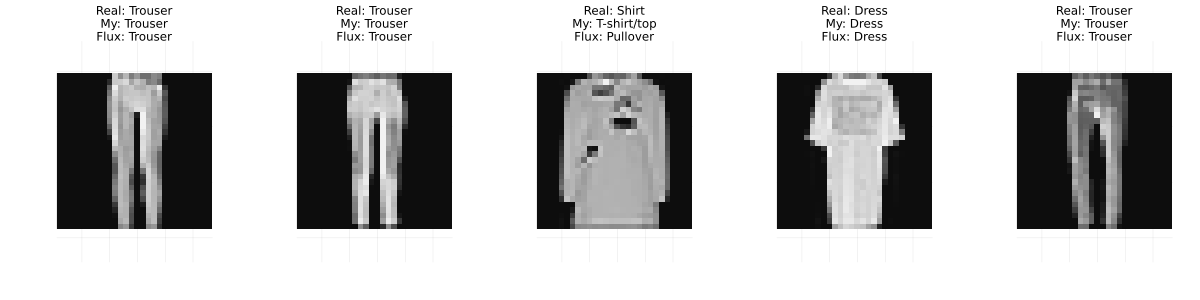

In [4]:
import Pkg
# Pkg.activate() 
# Pkg.add("Plots") 

using Plots
using Random

# https://github.com/zalandoresearch/fashion-mnist
const LABELS = Dict(
    0 => "T-shirt/top",
    1 => "Trouser",
    2 => "Pullover",
    3 => "Dress",
    4 => "Coat",
    5 => "Sandal",
    6 => "Shirt",
    7 => "Sneaker",
    8 => "Bag",
    9 => "Ankle boot"
)

num_images = 5
indices = rand(1:size(X_test, 4), num_images)

global IS_TRAINING = false
Flux.testmode!(flux_net)

plot_array = []

for (_, idx) in enumerate(indices)
    img_data = X_test[:, :, 1, idx]       
    true_label_idx = Y_test_raw[idx]      
    
    @views x_input = X_test[:, :, :, idx]
    forward!(my_model, input => x_input, target => zeros(10))
    my_pred_idx = argmax(output.data) - 1

    flux_out = flux_net(X_test[:, :, :, idx:idx]) 
    flux_pred_idx = Flux.onecold(flux_out, 0:9)[1]
    
    println("Obrazek $idx:")
    println("  Real:    ", LABELS[true_label_idx])
    println("  My:      ", LABELS[my_pred_idx])
    println("  Flux:    ", LABELS[flux_pred_idx])
    println("=======================")
    
    title_text = "Real: $(LABELS[true_label_idx])\nMy: $(LABELS[my_pred_idx])\nFlux: $(LABELS[flux_pred_idx])"
    
    p = heatmap(
        img_data', 
        yflip=true, 
        color=:grays, 
        legend=false, 
        aspect_ratio=:equal, 
        axis=false,
        title=title_text,
        titlefontsize=8
    )
    push!(plot_array, p)
end

plot(plot_array..., layout=(1, num_images), size=(1200, 300), margin=5Plots.mm)